In [1]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import pandas as pd
import matplotlib.pyplot as plt

from func_auxiliares.graficos_utils import set_style, init_base_plot
from func_auxiliares.config import ASSETS_DIR

# ─────────────────────── CONFIGURACIÓN GENERAL ───────────────────────
output_dir = ASSETS_DIR / "otros_graficos"
os.makedirs(output_dir, exist_ok=True)

set_style()  # Aplica el estilo corporativo unificado

In [2]:
años = [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
pib_real = [21809329, 22356265, 22732700, 23297736, 23929417, 24928062, 26030240, 27278913, 28524027, 30277826, 31294253, 32585680, 34281469, 36037460, 38486570, 40588156, 42559599, 44374306, 46235900, 48188730, 49256933, 44952919, 47700159, 49420074, 50943184, 51314663]
pib_nominal = [48156175, 51928492, 53790327, 56682328, 61904449, 69626113, 77023817, 91747795, 103009182, 120693764, 121726745, 137875568, 166231563, 187153878, 211856032, 228003659, 228031370, 234533182, 259184717, 278387647, 282586681, 253112221, 279206232, 304097235, 311885600, 322193425]

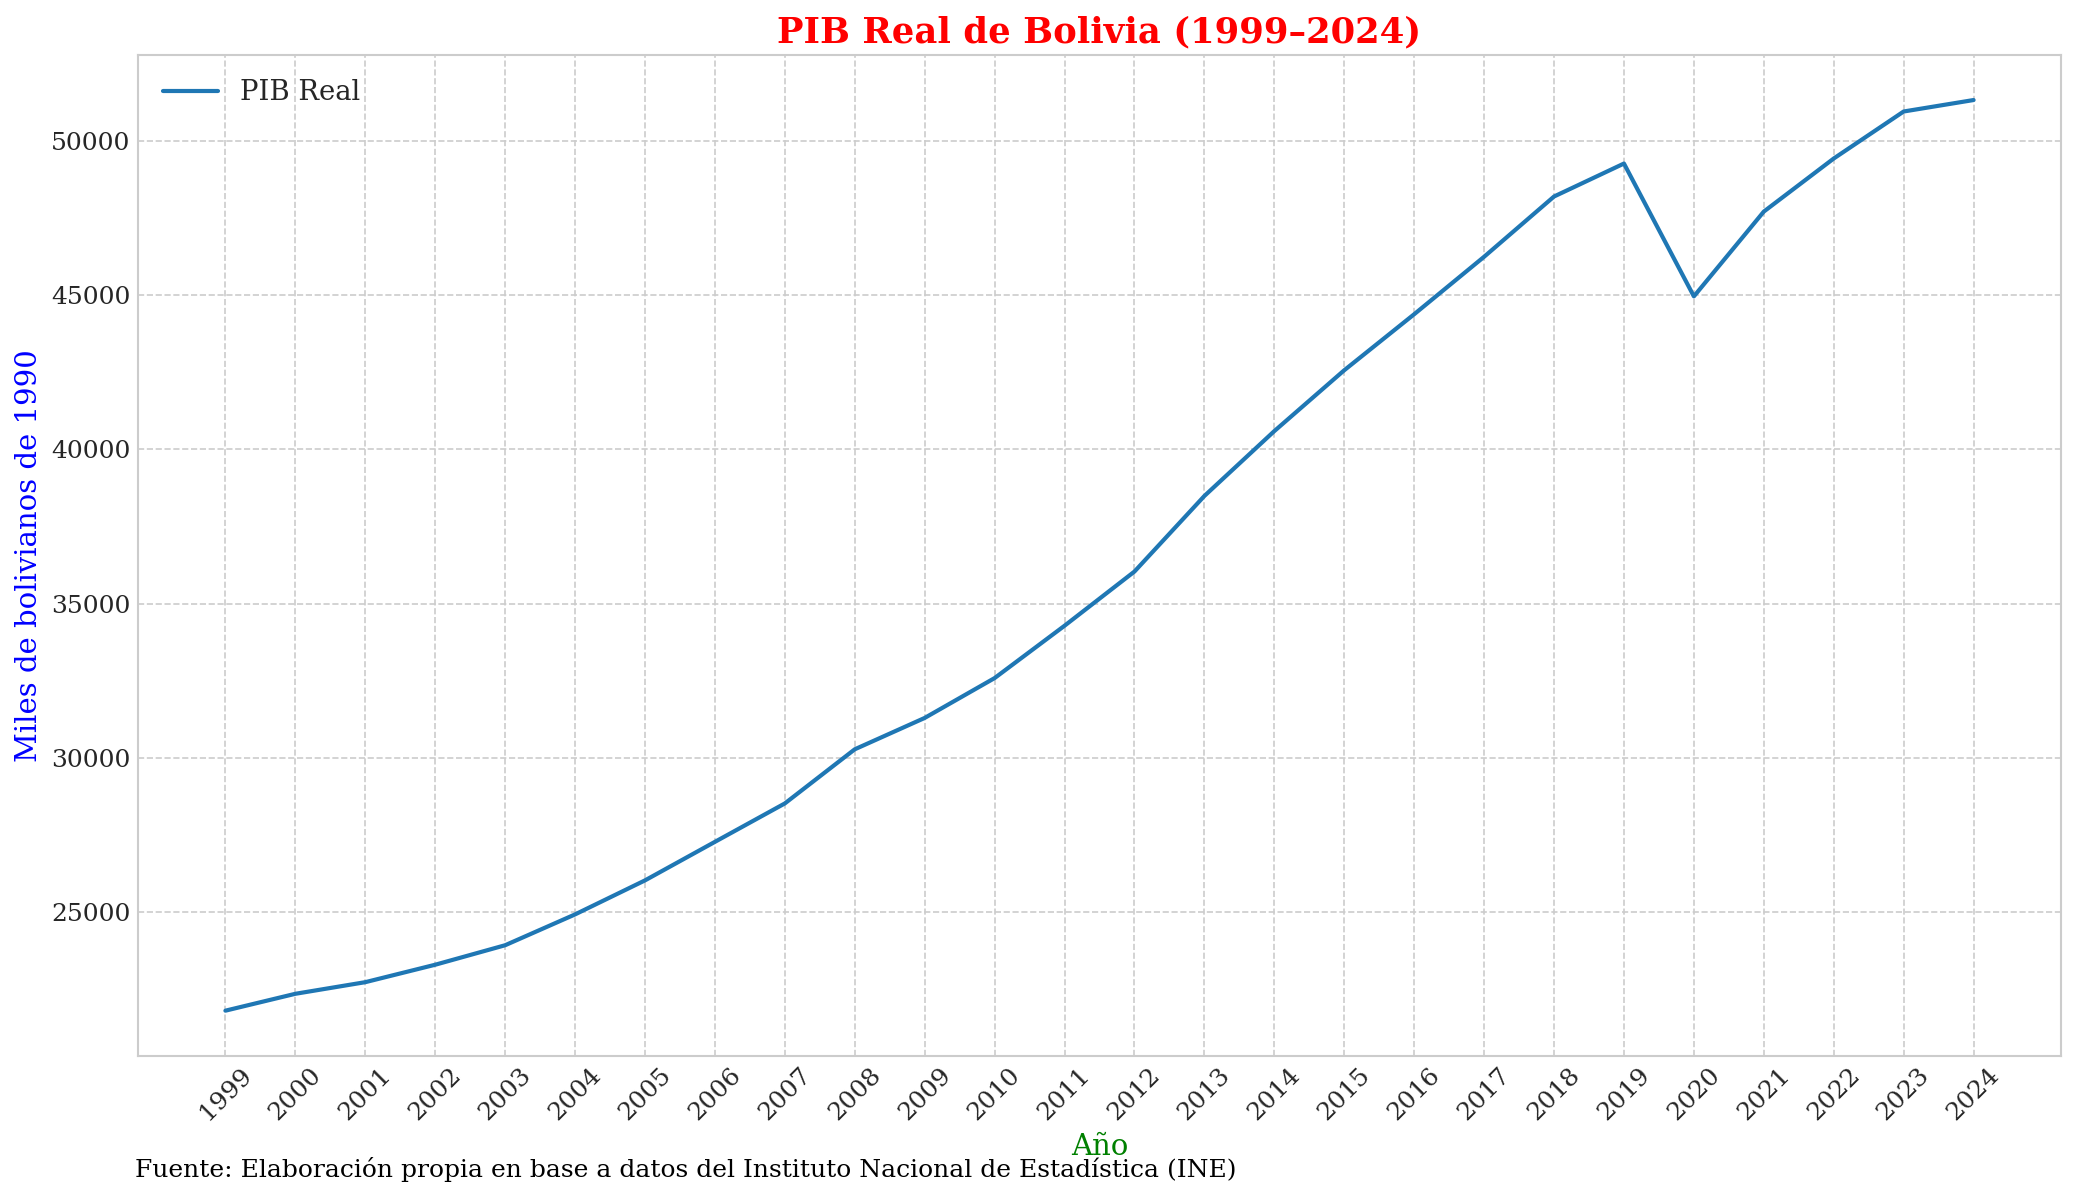

In [3]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA 1: PIB REAL
# ═══════════════════════════════════════════════════════════════════

# Crear DataFrame
df_real = pd.DataFrame({
    'año': años,
    'pib_real': pib_real
}).set_index('año')

# Convertir de bolivianos a miles de bolivianos
df_real['pib_real'] = df_real['pib_real'] / 1000

# Definir componentes y colores
componentes_real = [("pib_real", "PIB Real")]
colors_real = {"pib_real": "#1f77b4"}

# Crear gráfico base
fig, ax = init_base_plot(
    df=df_real,
    series=componentes_real,
    colors=colors_real,
    title=f"PIB Real de Bolivia ({df_real.index.min()}–{df_real.index.max()})",
    xlabel="Año",
    ylabel="Miles de bolivianos de 1990",
    source_text="Fuente: Elaboración propia en base a datos del Instituto Nacional de Estadística (INE)",
    figsize=(14, 8),
    legend_loc="upper left"
)

# Ajustes finales
plt.tight_layout()

# Guardar
filename_real = output_dir / "pib_real.png"


plt.show()
plt.close()

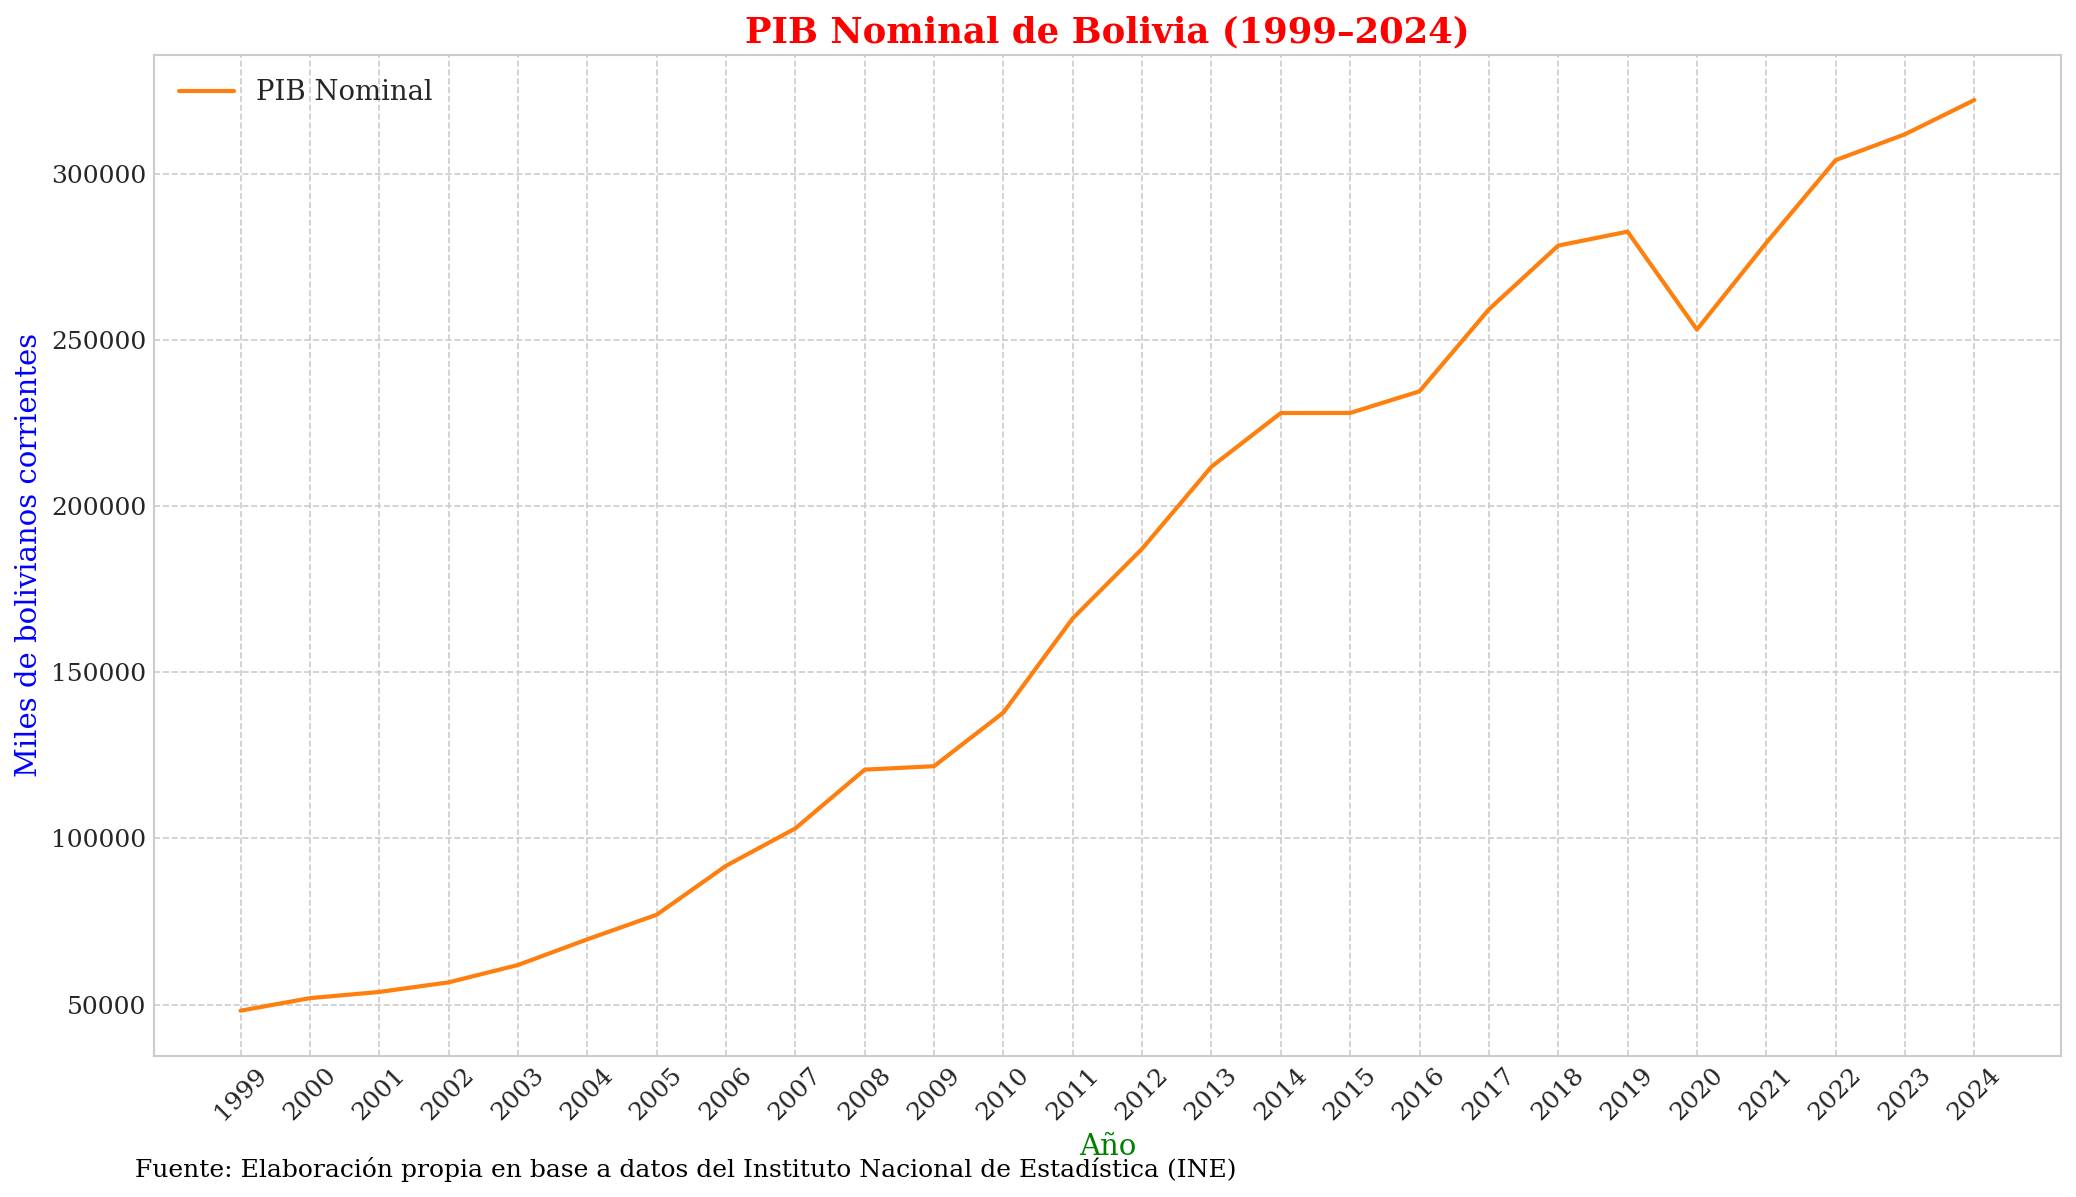

In [4]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA 2: PIB NOMINAL
# ═══════════════════════════════════════════════════════════════════

# Crear DataFrame
df_nominal = pd.DataFrame({
    'año': años,
    'pib_nominal': pib_nominal
}).set_index('año')

# Convertir de bolivianos a miles de bolivianos
df_nominal['pib_nominal'] = df_nominal['pib_nominal'] / 1000

# Definir componentes y colores
componentes_nominal = [("pib_nominal", "PIB Nominal")]
colors_nominal = {"pib_nominal": "#ff7f0e"}

# Crear gráfico base
fig, ax = init_base_plot(
    df=df_nominal,
    series=componentes_nominal,
    colors=colors_nominal,
    title=f"PIB Nominal de Bolivia ({df_nominal.index.min()}–{df_nominal.index.max()})",
    xlabel="Año",
    ylabel="Miles de bolivianos corrientes",
    source_text="Fuente: Elaboración propia en base a datos del Instituto Nacional de Estadística (INE)",
    figsize=(14, 8),
    legend_loc="upper left"
)

# Ajustes finales
plt.tight_layout()

# Guardar
filename_nominal = output_dir / "pib_nominal.png"


plt.show()
plt.close()

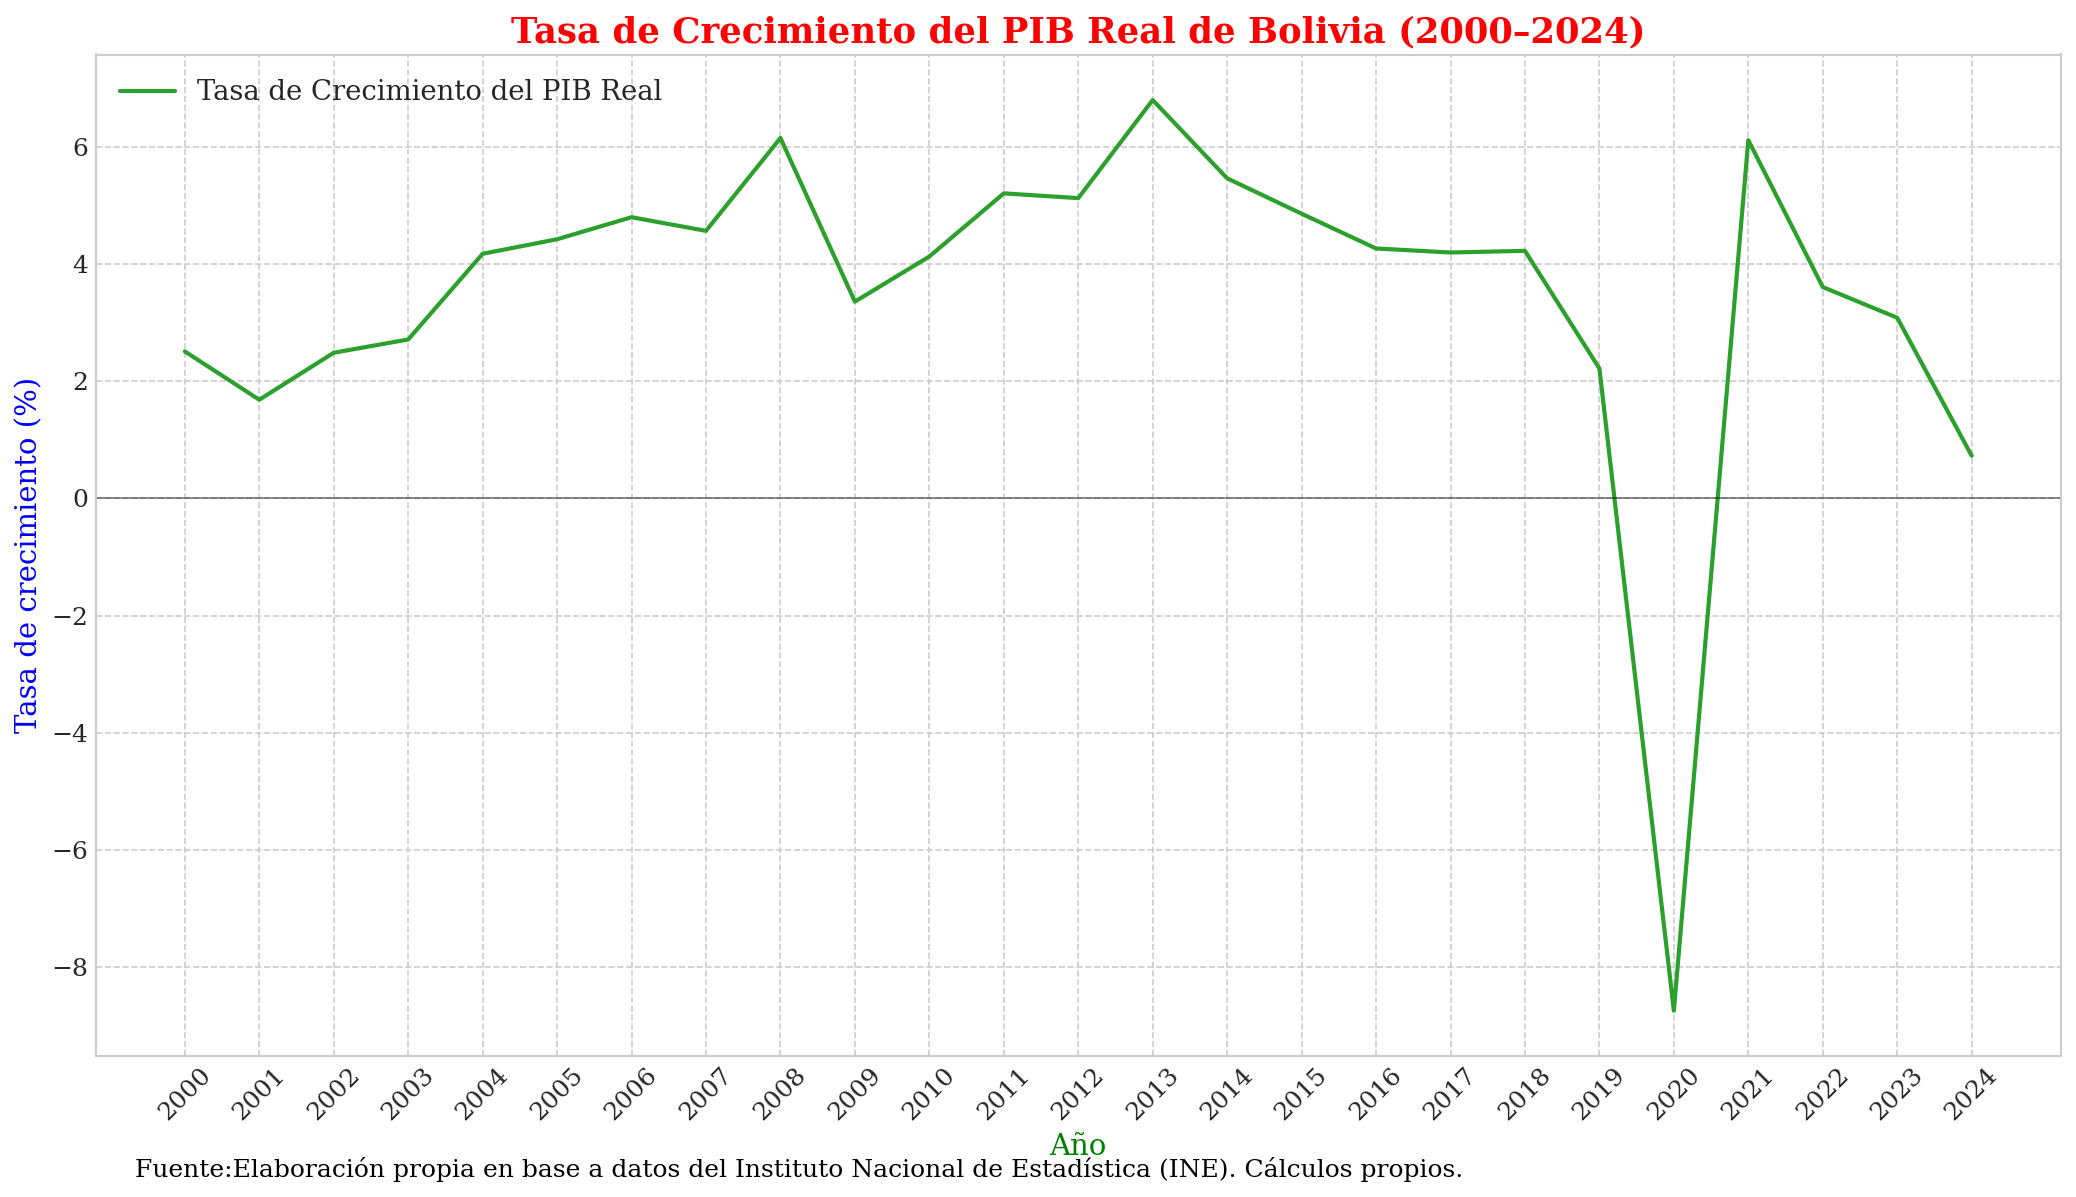


ESTADÍSTICAS DE LA TASA DE CRECIMIENTO DEL PIB REAL
Promedio: 3.52%
Mediana: 4.20%
Máximo: 6.80% (2013)
Mínimo: -8.74% (2020)
Desviación estándar: 2.94%


In [5]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA 3: TASA DE CRECIMIENTO DEL PIB REAL
# ═══════════════════════════════════════════════════════════════════

# Crear DataFrame con PIB real
df_tasa = pd.DataFrame({
    'año': años,
    'pib_real': pib_real
}).set_index('año')

# Calcular tasa de crecimiento anual (variación porcentual)
df_tasa['tasa_crecimiento'] = df_tasa['pib_real'].pct_change() * 100

# Eliminar el primer valor (NaN) ya que no tiene valor anterior
df_tasa = df_tasa.dropna()

# Definir componentes y colores
componentes_tasa = [("tasa_crecimiento", "Tasa de Crecimiento del PIB Real")]
colors_tasa = {"tasa_crecimiento": "#2ca02c"}

# Crear gráfico base
fig, ax = init_base_plot(
    df=df_tasa[['tasa_crecimiento']],
    series=componentes_tasa,
    colors=colors_tasa,
    title=f"Tasa de Crecimiento del PIB Real de Bolivia ({df_tasa.index.min()}–{df_tasa.index.max()})",
    xlabel="Año",
    ylabel="Tasa de crecimiento (%)",
    source_text="Fuente:Elaboración propia en base a datos del Instituto Nacional de Estadística (INE). Cálculos propios.",
    figsize=(14, 8),
    legend_loc="upper left"
)

# Agregar línea horizontal en 0 para referencia
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Ajustes finales
plt.tight_layout()

# Guardar
filename_tasa = output_dir / "tasa_crecimiento_pib_real.png"
fig.savefig(filename_tasa, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

# Mostrar estadísticas descriptivas
print("\n" + "="*60)
print("ESTADÍSTICAS DE LA TASA DE CRECIMIENTO DEL PIB REAL")
print("="*60)
print(f"Promedio: {df_tasa['tasa_crecimiento'].mean():.2f}%")
print(f"Mediana: {df_tasa['tasa_crecimiento'].median():.2f}%")
print(f"Máximo: {df_tasa['tasa_crecimiento'].max():.2f}% ({df_tasa['tasa_crecimiento'].idxmax()})")
print(f"Mínimo: {df_tasa['tasa_crecimiento'].min():.2f}% ({df_tasa['tasa_crecimiento'].idxmin()})")
print(f"Desviación estándar: {df_tasa['tasa_crecimiento'].std():.2f}%")
print("="*60)